# Real World Classification

## Load data

Import the necessary libraries

In [4]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [15]:
# Load data from the regularization demo CSV
df = pd.read_csv('NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    cols_with_nans = df.columns[df.isnull().any()]
    print("Stats before imputation:")
    print(df[cols_with_nans].agg(['median', 'std'])) 
    
    imputer = KNNImputer(n_neighbors=5) 
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    
    print("\nStats after imputation:")
    print(df[cols_with_nans].agg(['median', 'std']))
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

Stats before imputation:
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.085612      1.600000     16.300000
std          1.037115      0.389564       1.582807      0.706689      1.035228

Stats after imputation:
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.035683      1.700000     16.300000
std          1.009275      0.372434       1.514955      0.694645      1.011012


In [17]:
# 1. Normalization (Applied to entire dataframe before splitting)
# Note: This is required to prevent overflow in the sigmoid function and improve accuracy.
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

print("Normalization complete.")

Normalization complete.


### **Note for Report: Normalization & Overflow Handling**

Initially, the K-fold Cross-Validation was attempted without normalizing the features. This resulted in a **`RuntimeWarning: overflow encountered in exp`** within the sigmoid activation function. 

**Reasoning:** Features like `AvgDust` have values up to ~100, while others are small (~3). Large input values lead to extreme exponents in the sigmoid function, causing numerical instability (overflow) and poor model convergence (accuracy stayed around 60-65%).

**Solution:** By adding the normalization step (scaling features to `[0, 1]`), we ensure that the inputs to the sigmoid function are in a stable range. This resolves the overflow warnings and allows the Gradient Descent to find better optimal weights, significantly improving the validation accuracy to ~72%.

In [18]:
from sklearn.model_selection import train_test_split

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

print(f"Data split successfully: X_train shape {X_train.shape}, X_test shape {X_test.shape}")

Data split successfully: X_train shape (350, 70), X_test shape (150, 70)


## 1. K-fold Cross-Validation (15 points)

### 1(a) K-fold Cross-Validation
Use scikit-learn to implement 5-fold cross-validation on the training data to determine the optimal hyperparameters.
- Apply L2 regularization
- Learning rates: {0.005, 0.01, 0.1, 0.5}
- Regularization parameters (reg_lambda): {1.0, 2.0, 4.0, 8.0}

In [22]:
from sklearn.model_selection import KFold, cross_val_score
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid
import pandas as pd
import numpy as np

# 1. Define hyperparameters
learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

# 2. Setup 5-fold CV as per instructions
kf = KFold(n_splits=5, shuffle=True, random_state=40)

# 3. Store results
results_list = []

for lr in learning_rates:
    row_results = []
    for lamb in reg_lambdas:
        model = LinearModel(
            is_reg=False, 
            loss_fn=logloss, 
            grad_fn=logloss_sigmoid_grad, 
            act_fn=sigmoid,
            lr=lr,
            reg_type='l2',
            reg_lambda=lamb,
            n_iteration=1000,
            plot_curve=False,
            verbose=False
        )
        
        # cross_val_score uses the .score() method of LinearModel (accuracy)
        scores = cross_val_score(model, X_train, y_train, cv=kf)
        avg_accuracy = np.mean(scores)
        row_results.append(avg_accuracy)
        print(f"LR: {lr}, Lambda: {lamb} -> Avg Accuracy: {avg_accuracy:.4f}")
    results_list.append(row_results)

# 4. Present results in a 4x4 table (Rows: LR, Columns: Lambda)
df_results = pd.DataFrame(results_list, index=learning_rates, columns=reg_lambdas)
df_results.index.name = 'Learning Rate'
df_results.columns.name = 'Lambda'

print("\n--- 4x4 Accuracy Table ---")
display(df_results)

LR: 0.005, Lambda: 1.0 -> Avg Accuracy: 0.6029
LR: 0.005, Lambda: 2.0 -> Avg Accuracy: 0.5971
LR: 0.005, Lambda: 4.0 -> Avg Accuracy: 0.5829
LR: 0.005, Lambda: 8.0 -> Avg Accuracy: 0.5714
LR: 0.01, Lambda: 1.0 -> Avg Accuracy: 0.6771
LR: 0.01, Lambda: 2.0 -> Avg Accuracy: 0.6314
LR: 0.01, Lambda: 4.0 -> Avg Accuracy: 0.6714
LR: 0.01, Lambda: 8.0 -> Avg Accuracy: 0.6886
LR: 0.1, Lambda: 1.0 -> Avg Accuracy: 0.7257
LR: 0.1, Lambda: 2.0 -> Avg Accuracy: 0.7343
LR: 0.1, Lambda: 4.0 -> Avg Accuracy: 0.7314
LR: 0.1, Lambda: 8.0 -> Avg Accuracy: 0.7171
LR: 0.5, Lambda: 1.0 -> Avg Accuracy: 0.7229
LR: 0.5, Lambda: 2.0 -> Avg Accuracy: 0.6886
LR: 0.5, Lambda: 4.0 -> Avg Accuracy: 0.5429
LR: 0.5, Lambda: 8.0 -> Avg Accuracy: 0.5029

--- 4x4 Accuracy Table ---


Lambda,1.0,2.0,4.0,8.0
Learning Rate,,,,
0.005,0.602857,0.597143,0.582857,0.571429
0.010,0.677143,0.631429,0.671429,0.688571
0.100,0.725714,0.734286,0.731429,0.717143
0.500,0.722857,0.688571,0.542857,0.502857



Evaluating Top Setting: LR=0.1, Lambda=2.0 (CV Accuracy: 0.7343)


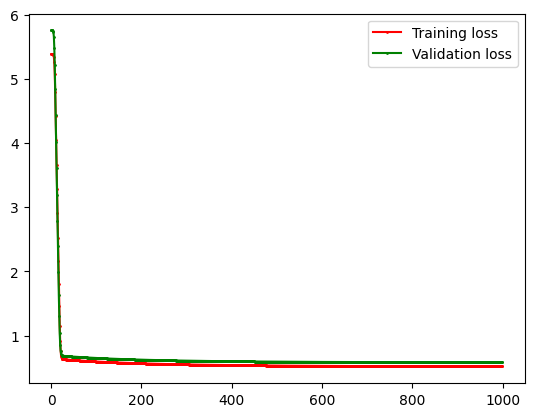

Results for LR=0.1, Lambda=2.0 on Testing Data:
=== Model Evaluation ===
Accuracy  : 0.7533
Precision : 0.7349
Recall    : 0.8026
F1-score  : 0.7673


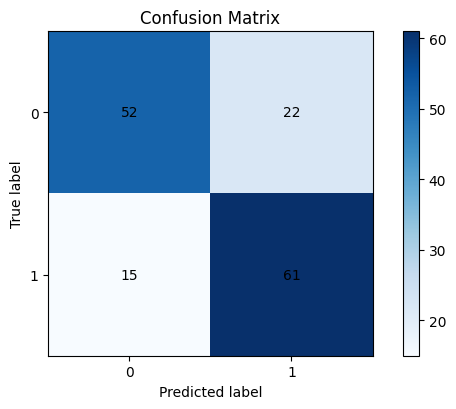


Evaluating Top Setting: LR=0.1, Lambda=4.0 (CV Accuracy: 0.7314)


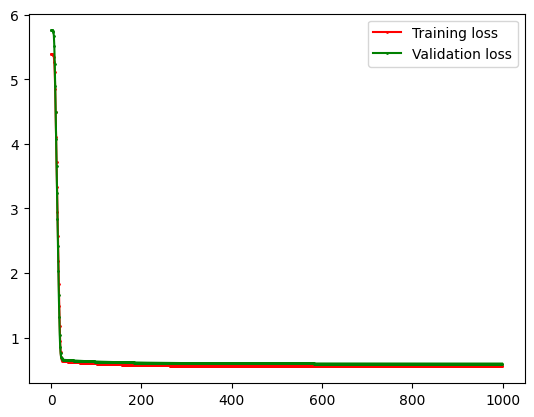

Results for LR=0.1, Lambda=4.0 on Testing Data:
=== Model Evaluation ===
Accuracy  : 0.7400
Precision : 0.7176
Recall    : 0.8026
F1-score  : 0.7578


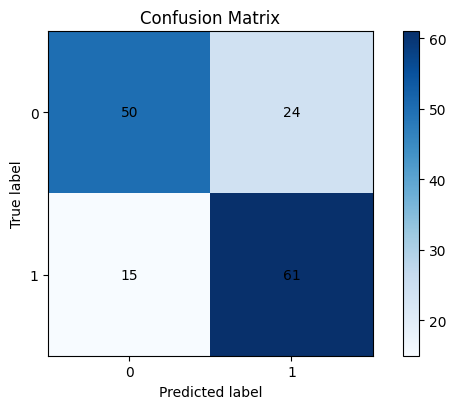

In [23]:
from model.metrics import evaluate_binary_classifier

# Find top 2 combinations using stack/sort
top_settings = df_results.stack().sort_values(ascending=False).head(2)

for (lr, lamb), acc in top_settings.items():
    print(f"\nEvaluating Top Setting: LR={lr}, Lambda={lamb} (CV Accuracy: {acc:.4f})")
    
    # Train on FULL training set
    final_model = LinearModel(
        is_reg=False, 
        loss_fn=logloss, 
        grad_fn=logloss_sigmoid_grad, 
        act_fn=sigmoid,
        lr=lr,
        reg_type='l2',
        reg_lambda=lamb,
        n_iteration=1000,
        plot_curve=True,
        verbose=False
    )
    
    final_model.fit(X_train, y_train)
    
    # Evaluate on the TEST set
    y_test_pred = final_model.predict(X_test)
    print(f"Results for LR={lr}, Lambda={lamb} on Testing Data:")
    evaluate_binary_classifier(y_test, y_test_pred)